In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from ion_simulbox import Ion
from ion_simulbox.laser import Laser, Polarization, EnvelopeFactory
from ion_simulbox.experiment import Experiment
from ion_simulbox.units import Units, Constants
from ion_simulbox.utils import get_resonant_frequency, intensity_from_power_and_radius
from ion_simulbox.transition import Transition

In [3]:
from ion_simulbox.systems.i_system import ISystem
from ion_simulbox.systems.lambda_system import LambdaSystem
from ion_simulbox.systems.i_lambda_system import ILambdaSystem
from ion_simulbox.systems.scheduled_system import ScheduledSystem

In [4]:
import matplotlib.pyplot as plt

In [5]:
ion = Ion("Ba", 138)

## 1. Juggling with 585 and 614

In [6]:
t_rep = 10*1e-9

In [7]:
ion.apply_magnetic_field(2e-4*Units.T)

In [26]:
n_juggle = 40
step_time = 50*Units.ns
power_650 = 5e-9
pulse_time = 5 * Units.ps
pulse_intensity = 50e8


system = ScheduledSystem(
    ion=ion,
    BaseSystem=LambdaSystem,
    system_parameters={
        "lower_states_1": ion.zeeman_levels[ion.get_level("6S0.5")],
        "lower_states_2": ion.zeeman_levels[ion.get_level("5D1.5")],
        "upper_states": ion.zeeman_levels[ion.get_level("6P0.5")],
        "reference_state": ion.zeeman_levels[ion.get_level("6P0.5")][0],
    },
    time_duration=50*Units.ns * n_juggle,
    base_lasers={
        "laser_1": Laser(
            name="493 nm",
            frequency=get_resonant_frequency(ion.get_level("6S0.5"), ion.get_level("6P0.5")),
            intensity=0,
            line_width=10 * Units.kHz, 
            polarization=Polarization(-np.array([0, 0, 1]), 1 / np.sqrt(2), 1j / np.sqrt(2))
        ),
        "laser_2": Laser(
            name="650 nm",
            frequency=get_resonant_frequency(ion.get_level("5D1.5"), ion.get_level("6P0.5")) + 10*Units.MHz,
            intensity=intensity_from_power_and_radius(0e-6, 30e-6), 
            line_width=10 * Units.kHz, 
            polarization=Polarization(np.array([0, 1, 1])/np.sqrt(2), 1, 0)
        )
    },
    base_envelope_functions={
        "envelope_function_1": None,
        "envelope_function_2": None,
    }
)

for i in range(n_juggle):
    if i % 2 == 0:
        system.add_schedule(
            50*Units.ns * i, 50*Units.ns * (i + 1), 
            laser_parameters={
                "laser_1": Laser(
                    name="493 nm",
                    frequency=get_resonant_frequency(ion.get_level("6S0.5"), ion.get_level("6P0.5")),
                    intensity=pulse_intensity,
                    line_width=10 * Units.kHz, 
                    polarization=Polarization(-np.array([0, 0, 1]), 1 / np.sqrt(2), 1j / np.sqrt(2))
                ),
                "laser_2": Laser(
                    name="650 nm",
                    frequency=get_resonant_frequency(ion.get_level("5D1.5"), ion.get_level("6P0.5")) + 10*Units.MHz,
                    intensity=intensity_from_power_and_radius(power_650, 30e-6), 
                    line_width=10 * Units.kHz, 
                    polarization=Polarization(np.array([0, 1, 1])/np.sqrt(2), 1, 0)
                )
            },
            envelope_functions={
                "envelope_function_1": EnvelopeFactory.gaussian_factory(step_time * i + 5 * pulse_time, pulse_time),
                "envelope_function_2": EnvelopeFactory.square_factory(0, 1)
            }


        )
    else:
        system.add_schedule(
            50*Units.ns * i, 50*Units.ns * (i + 1), 
            laser_parameters={
                "laser_1": Laser(
                    name="493 nm",
                    frequency=get_resonant_frequency(ion.get_level("6S0.5"), ion.get_level("6P0.5")),
                    intensity=pulse_intensity,
                    line_width=10 * Units.kHz, 
                    polarization=Polarization(-np.array([0, 0, 1]), 1 / np.sqrt(2), -1j / np.sqrt(2))
                ),
                "laser_2": Laser(
                    name="650 nm",
                    frequency=get_resonant_frequency(ion.get_level("5D1.5"), ion.get_level("6P0.5")) + 10*Units.MHz,
                    intensity=intensity_from_power_and_radius(power_650, 30e-6), 
                    line_width=10 * Units.kHz, 
                    polarization=Polarization(np.array([0, 1, 1])/np.sqrt(2), 1, 0)
                )
            },
            envelope_functions={
                "envelope_function_1": EnvelopeFactory.gaussian_factory(step_time * i + 5 * pulse_time, pulse_time),
                "envelope_function_2": EnvelopeFactory.square_factory(0, 1)
            }


        )
system.finalize_schedule()

In [27]:
t_list = np.linspace(0, n_juggle * step_time, 1001)

In [ ]:
initial_state = system.basis[ion.zeeman_levels[ion.get_level("6S0.5")][0]]
expect_values, initial_state = system.solve(initial_state, t_list)

10.0%. Run time:  13.47s. Est. time left: 00:00:02:01
20.0%. Run time:  30.89s. Est. time left: 00:00:02:03
30.0%. Run time:  52.06s. Est. time left: 00:00:02:01
40.0%. Run time:  66.56s. Est. time left: 00:00:01:39
50.0%. Run time:  83.84s. Est. time left: 00:00:01:23


In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)
S_m = expect_values['6S0.5 m_J=-0.5']
S_p = expect_values['6S0.5 m_J=0.5']
D_three_half = (
    expect_values['5D1.5 m_J=-1.5'] 
    + expect_values['5D1.5 m_J=-0.5'] 
    + expect_values['5D1.5 m_J=0.5'] 
    + expect_values['5D1.5 m_J=1.5'] 
)

P_one_half = expect_values['6P0.5 m_J=-0.5'] + expect_values['6P0.5 m_J=0.5']

ax.plot(t_list/1e-6, S_m, label=r"P(|0>)")
ax.plot(t_list/1e-6, S_p, label=r"P(|1>)")
ax.plot(t_list/1e-6, P_one_half, label=r"P(P_1/2)")
ax.plot(t_list/1e-6, D_three_half, label=r"P(D_3/2)")
ax.legend()
ax.set_ylabel("Population")
ax.set_xlabel("Time (us)")
ax.grid()

In [318]:
T_c_list = np.linspace(0.1e-6, 2.25e-6, 10001)
T_rep_c = 1e-6
T_rep_e = 13e-9
tau = 4.5 * T_rep_e
T_e_list = -tau / 2 * np.log(1 - 2 * T_c_list * T_rep_e / (T_rep_c * tau))
T_c_list[-1] = 2.25e-6
T_e_list[-1] = 1e32

/var/folders/pv/t5bfz32d1f702t83__0z626w0000gn/T/ipykernel_1658/632533966.py:5: RuntimeWarning: divide by zero encountered in log
  T_e_list = -tau / 2 * np.log(1 - 2 * T_c_list * T_rep_e / (T_rep_c * tau))


In [319]:
T_e_list

array([1.32977444e-09, 1.33269959e-09, 1.33562503e-09, ...,
       2.50457675e-07, 2.70732230e-07, 1.00000000e+32])

Text(0, 0.5, 'Time with juggling (us)')

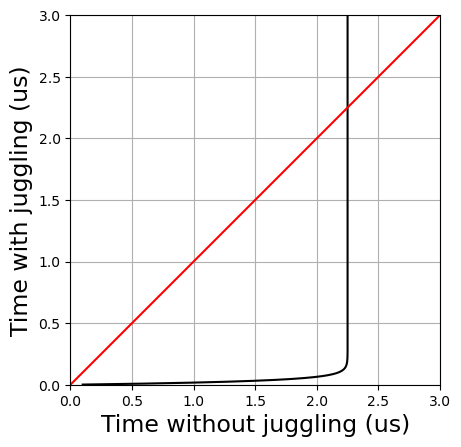

In [146]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(T_c_list / 1e-6, T_e_list / 1e-6, c='k')
ax.set_aspect('equal')
ax.grid()
ax.set_ylim([0, 3])
ax.set_xlim([0, 3])
ax.plot(np.linspace(0,3e-6, 11) / 1e-6, np.linspace(0,3e-6, 11) / 1e-6, c='r')
ax.set_xlabel('Time without juggling (us)', fontsize=17)
ax.set_ylabel('Time with juggling (us)', fontsize=17)

In [519]:
2.25/13e-3

173.0769230769231

In [341]:
1.25 / 50e-3

25.0

In [347]:
list(ion.decay_channels.keys())[0][0].name

'6P0.5 m_J=-0.5'

(0.0, 0.25)

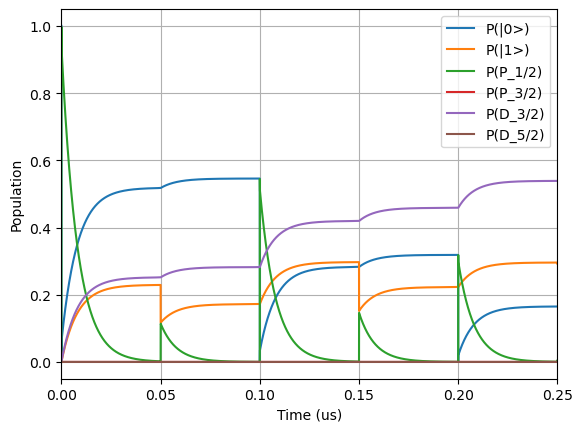

In [307]:
fig = plt.figure()
ax = fig.add_subplot(111)
S_m = expect_values['6S0.5 m_J=-0.5']
S_p = expect_values['6S0.5 m_J=0.5']
D_three_half = (
    expect_values['5D1.5 m_J=-1.5'] 
    + expect_values['5D1.5 m_J=-0.5'] 
    + expect_values['5D1.5 m_J=0.5'] 
    + expect_values['5D1.5 m_J=1.5'] 
)
D_five_half = (
    expect_values['5D2.5 m_J=-2.5'] 
    + expect_values['5D2.5 m_J=-1.5'] 
    + expect_values['5D2.5 m_J=-0.5'] 
    + expect_values['5D2.5 m_J=0.5'] 
    + expect_values['5D2.5 m_J=1.5'] 
    + expect_values['5D2.5 m_J=2.5'] 
)
P_one_half = expect_values['6P0.5 m_J=-0.5'] + expect_values['6P0.5 m_J=0.5']
P_three_half = (
    expect_values['6P1.5 m_J=-1.5'] 
    + expect_values['6P1.5 m_J=-0.5'] 
    + expect_values['6P1.5 m_J=0.5'] 
    + expect_values['6P1.5 m_J=1.5'] 
)

ax.plot(t_list_total/1e-6, S_m, label=r"P(|0>)")
ax.plot(t_list_total/1e-6, S_p, label=r"P(|1>)")
ax.plot(t_list_total/1e-6, P_one_half, label=r"P(P_1/2)")
ax.plot(t_list_total/1e-6, P_three_half, label=r"P(P_3/2)")
ax.plot(t_list_total/1e-6, D_three_half, label=r"P(D_3/2)")
ax.plot(t_list_total/1e-6, D_five_half, label=r"P(D_5/2)")
ax.legend()
ax.set_ylabel("Population")
ax.set_xlabel("Time (us)")
ax.grid()
ax.set_xlim([0, 0.25])

## 2. Pulse excitation

In [10]:
laser_493 = Laser(
    name="493 nm",
    frequency=get_resonant_frequency(ion.energy_levels[0], ion.energy_levels[1]),
    intensity=9.1e8,
    line_width=10 * Units.kHz, 
    polarization=Polarization(-np.array([0, 0, 1]), 1 / np.sqrt(2), 1j / np.sqrt(2))
)

In [11]:
system = SingleLaserSystem(
    ion=ion,
    lower_states=ion.zeeman_levels[ion.get_level("6S0.5")],
    upper_states=ion.zeeman_levels[ion.get_level("6P0.5")],
    laser=laser_493,
    envelope_function=EnvelopeFactory.gaussian_factory(50e-12, 10e-12),
    reference_state=ion.zeeman_levels[ion.get_level("6S0.5")][0],
)

In [12]:
initial_state = system.basis[ion.zeeman_levels[ion.get_level("6S0.5")][0]]
t_list = np.linspace(0, 100000, 30001) * 1e-12
expect_values, final_state = system.solve(initial_state, t_list)

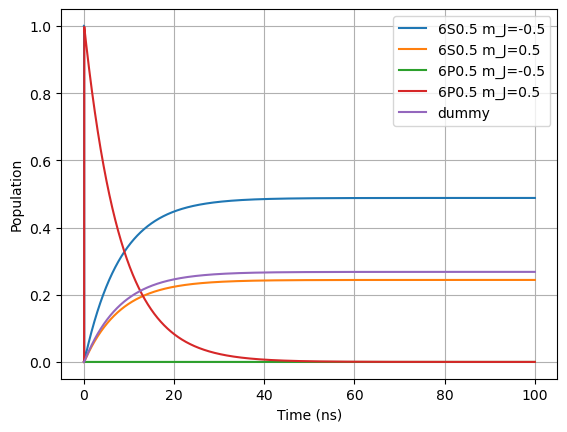

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111)
for name, expect in expect_values.items():
    ax.plot(t_list/1e-9, expect, label=name)
ax.legend()
ax.set_ylabel("Population")
ax.set_xlabel("Time (ns)")
ax.grid()

## Initialization single detuning

In [24]:
ion.apply_magnetic_field(4e-4*Units.T)

In [36]:
laser_493 = Laser(
    name="493 nm",
    frequency=get_resonant_frequency(ion.energy_levels[0], ion.energy_levels[1]) + 0 * Units.MHz,
    intensity=400, # 9.1e8 
    line_width=10 * Units.kHz, 
    polarization=Polarization(-np.array([0, 0, 1]), 1 / np.sqrt(2), 1j / np.sqrt(2))
)

In [49]:
laser_650 = Laser(
    name="650 nm",
    frequency=get_resonant_frequency(ion.energy_levels[1], ion.energy_levels[3]) + 10 * Units.MHz,
    intensity=500, 
    line_width=10 * Units.kHz, 
    # polarization=Polarization(-np.array([1, 0, 0]), 1 / np.sqrt(2), 1j / np.sqrt(2))
    polarization=Polarization(np.array([0, 1, 1])/np.sqrt(2), 1, 0)
)

In [50]:
system = LambdaSystem(
    ion=ion,
    lower_states_1=ion.zeeman_levels[ion.get_level("6S0.5")],
    lower_states_2=ion.zeeman_levels[ion.get_level("5D1.5")],
    upper_states=ion.zeeman_levels[ion.get_level("6P0.5")],
    laser_1=laser_493,
    laser_2=laser_650,
    envelope_function_1=EnvelopeFactory.square_factory(0, 100000e-9),
    envelope_function_2=EnvelopeFactory.square_factory(0, 100000e-9),
    reference_state=ion.zeeman_levels[ion.get_level("6P0.5")][0],
)

In [51]:
initial_state = system.basis[ion.zeeman_levels[ion.get_level("6S0.5")][0]]
t_list = np.linspace(0, 6000, 5001) * 1e-9
expect_values, final_state = system.solve(initial_state, t_list)

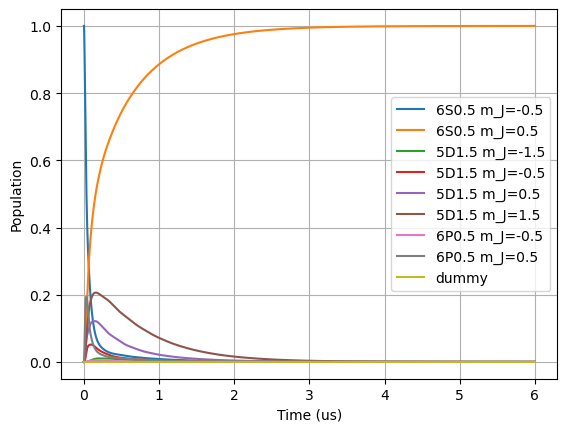

In [52]:
fig = plt.figure()
ax = fig.add_subplot(111)
for name, expect in expect_values.items():
    ax.plot(t_list/1e-6, expect, label=name)
ax.legend()
ax.set_ylabel("Population")
ax.set_xlabel("Time (us)")
ax.grid()

## Initialization single detuning sweep

In [6]:
ion.apply_magnetic_field(1e-8*Units.T)

In [8]:
intensity_493_list = np.linspace(50, 300, 31)
intensity_650_list = np.linspace(0, 100000, 51)
population_S_1 = []
population_S_2 = []

population_P = []
population_D = []
population_dummy = []
for intensity_493 in intensity_493_list:
    print("#", end="")
    population_S_1.append([])
    population_S_2.append([])
    population_P.append([])
    population_D.append([])
    population_dummy.append([])
    for intensity_650 in intensity_650_list:
        print("*", end="")
        laser_493 = Laser(
            name="493 nm",
            frequency=get_resonant_frequency(ion.energy_levels[0], ion.energy_levels[1]),
            intensity=intensity_493, # 9.1e8 
            line_width=10 * Units.kHz, 
            polarization=Polarization(-np.array([0, 0, 1]), 1 / np.sqrt(2), 1j / np.sqrt(2))
        )
        laser_650 = Laser(
            name="650 nm",
            frequency=get_resonant_frequency(ion.energy_levels[1], ion.energy_levels[3]) + 5*Units.MHz,
            intensity=intensity_650, 
            line_width=10 * Units.kHz, 
            # polarization=Polarization(-np.array([1, 0, 0]), 1 / np.sqrt(2), 1j / np.sqrt(2))
            polarization=Polarization(np.array([0, 1, 1])/np.sqrt(2), 1, 0)
        )
        
        system = LambdaSystem(
            ion=ion,
            lower_states_1=ion.zeeman_levels[ion.get_level("6S0.5")],
            lower_states_2=ion.zeeman_levels[ion.get_level("5D1.5")],
            upper_states=ion.zeeman_levels[ion.get_level("6P0.5")],
            laser_1=laser_493,
            laser_2=laser_650,
            envelope_function_1=EnvelopeFactory.square_factory(0, 50000e-9),
            envelope_function_2=EnvelopeFactory.square_factory(0, 50000e-9),
            reference_state=ion.zeeman_levels[ion.get_level("6P0.5")][0],
        )
        initial_state = system.basis[ion.zeeman_levels[ion.get_level("6S0.5")][0]]
        t_list = np.linspace(0, 10000, 3001) * 1e-9
        expect_values, final_state = system.solve(initial_state, t_list)
        P_S_1 = 0
        P_S_2 = 0
        P_P = 0
        P_D = 0
        P_dummy = 0
        for k, v in expect_values.items():
            if "S" in k:
                if "m_J=-0.5" in k:
                    P_S_1 = P_S_1 + v
                elif "m_J=0.5" in k:
                    P_S_2 = P_S_2 + v
            elif "P" in k:
                P_P = P_P + v
            elif "D" in k:
                P_D = P_D + v 
            else:
                P_dummy = P_dummy + v
        population_S_1[-1].append(P_S_1)
        population_S_2[-1].append(P_S_2)
        population_P[-1].append(P_P)
        population_D[-1].append(P_D)
        population_dummy[-1].append(P_dummy)
    print("")

#***************************************************
#***************************************************
#***************************************************
#***************************************************
#***************************************************
#***************************************************
#***************************************************
#***************************************************
#***************************************************
#***************************************************
#***************************************************
#***************************************************
#***************************************************
#***************************************************
#***************************************************
#***************************************************
#***************************************************
#***************************************************
#*********************************************

In [16]:
ion.zeeman_levels[ion.get_level("6S0.5")][0]

6S0.5 m_J=-0.5

Text(0, 0.5, '650nm detuning')

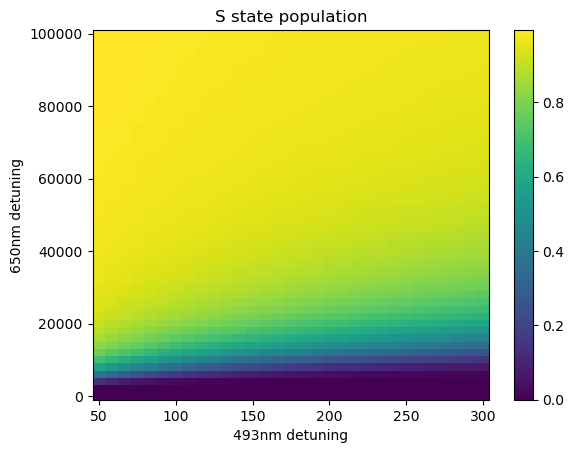

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111)
p = ax.pcolormesh(intensity_493_list, intensity_650_list, np.array(population_S_1)[..., -1].T)
plt.colorbar(p)
ax.set_title("S state population")
ax.set_xlabel("493nm detuning")
ax.set_ylabel("650nm detuning")

Text(0, 0.5, '650nm detuning')

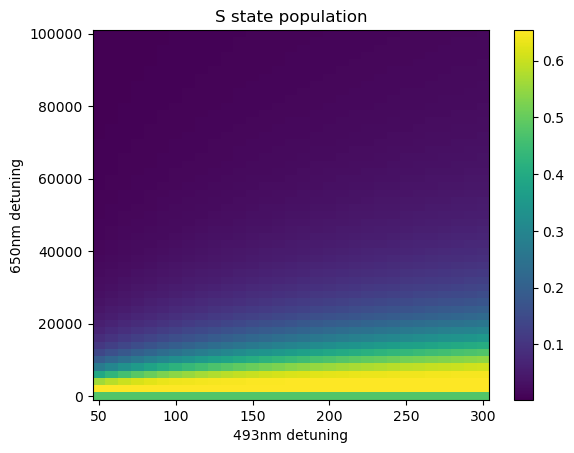

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111)
p = ax.pcolormesh(intensity_493_list, intensity_650_list, np.array(population_S_2)[..., -1].T)
plt.colorbar(p)
ax.set_title("S state population")
ax.set_xlabel("493nm detuning")
ax.set_ylabel("650nm detuning")

Text(0, 0.5, '650nm detuning')

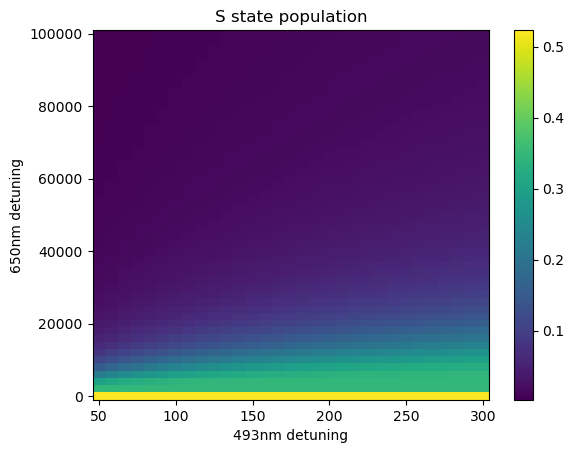

In [23]:
fig = plt.figure()
ax = fig.add_subplot(111)
p = ax.pcolormesh(intensity_493_list, intensity_650_list, np.array(population_D)[..., -1].T)
plt.colorbar(p)
ax.set_title("S state population")
ax.set_xlabel("493nm detuning")
ax.set_ylabel("650nm detuning")

Text(0, 0.5, '650nm detuning')

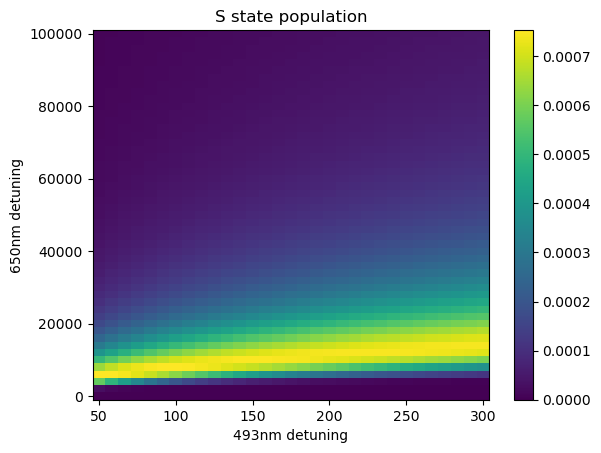

In [18]:
fig = plt.figure()
ax = fig.add_subplot(111)
p = ax.pcolormesh(intensity_493_list, intensity_650_list, np.array(population_P)[..., -1].T)
plt.colorbar(p)
ax.set_title("S state population")
ax.set_xlabel("493nm detuning")
ax.set_ylabel("650nm detuning")